## El siguiente ejemplo muestra algunas ideas para automatizar transformaciones y evitar la fuga de datos.

Ajustado el 21/05/2026, sepan entender cualquier error!

In [126]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.datasets import make_classification
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report
from sklearn.compose import ColumnTransformer

In [127]:
#Imputador con columnas, estrategia: composición
class Plantilla(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass        
    def fit(self, X, y=None):
        return self    
    def get_feature_names_out(self):
        return None
    def transform(self, X):
        return None

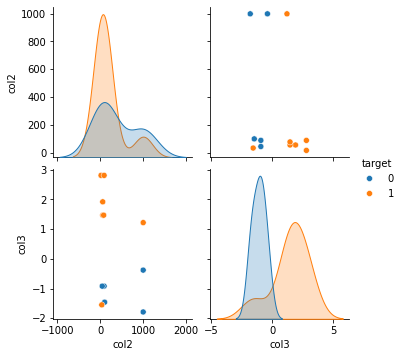

In [128]:
df = pd.DataFrame({"col1":[33, 99, 55, 99, 999, 55,  "16", 999,  33, 999, 44, 55, 88, 55],
                   "col2":[88, 99, 55, 99, 999, 55,  16, 999,  91, 999, 44, 77, 88, 33],
                   "col3":[-0.92, -1.46,  1.92 , np.nan , -0.38, 1.47,  2.81, -1.79, np.nan,  1.22, -0.92, 1.47,  2.81, -1.55],
                   "cat":  ["B", "B", "M", "B", "B", "M", "M", "B", "M", "M", "B", "M", "M", "B"],
                   "target":[0,   0,   1,   0,   0,   1,   1,   0,   1,   1,   0,   1,   1,   1]})
sns.pairplot(df[["col1", "col2", "col3", "target"]], hue='target')


A pesar de que ahora sklearn permite trabajar con índice por columna el valor de los transformadores customizados persiste. No todas las transformaciones están disponibles. Ejemplo, 1.Imputar la media a los valores 999, 2.Categorizar por femenino / masculino según el titulo del nombre Sr. Juan Perez, Sra. Maria Garcia. 3.Quitar columnas con determinada colinealidad. Los transformadores customizados, si cumplen determinadas reglas se insertar de forma transparente tanto en ColumnTransformer como en Pipelines.

In [129]:
X = df.drop("target", axis=1)
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=3, test_size=0.3)

Una solución relativamente sencilla (a mi juicio la mejor) de aplicar transformaciones es crear transformadores customizados, muchas veces son simplemente envoltorios o "wrappers" de clases sklearn. Solo hay que implementar algunos métodos para que la clase Pipeline pueda hacer las transformaciones en orden. 

Arranquemos con un normalizador de tipos mas potente.

In [130]:
class TypeSelector(BaseEstimator, TransformerMixin):
    def __init__(self, dtype_map):
        self.dtype_map = dtype_map # Ejemplo: {'col1': 'float', 'col2': 'int'}
        
    def fit(self, X, y=None):
        return self
        
    def transform(self, X):
        X = X.copy()
        return X.astype(self.dtype_map)


In [131]:
#Imputador con columnas, estrategia: composicion
#Y no asumir nada hasta no terminar de ver el notebook
class IntegerImputer(BaseEstimator, TransformerMixin):
    #Este constructor es muy tentador pero genera problemas al momento de usarlo en un gridsearch sobre un pipeline
    def __init__(self, strategy='mean', number=999):
        super().__init__()
        self.strategy = strategy
        self.number = number
        self.imputer = None
        
    def fit(self, X, y=None):
        self.imputer = SimpleImputer(strategy=self.strategy)
        #Si me interesa mantener el formato de dataframe
        self.imputer.set_output(transform="pandas")
        self.imputer.fit(X)
        return self    
    
    def get_feature_names_out(self):
        return self.imputer.get_feature_names_out()
    
    def transform(self, X):
        Xc = X.copy()        
        #Xc.loc[:, self.imputer.get_feature_names_out()] también funciona?
        if isinstance(Xc, pd.DataFrame):
            Xc = Xc.replace(self.number, np.nan)
        elif isinstance(Xc, np.ndarray):
            Xc = np.where(Xc == self.number, np.nan, Xc)
        else:
            raise TypeError("Input type not supported. Expected pandas DataFrame or numpy array.")

        Xc = self.imputer.transform(Xc)
        return Xc

In [132]:
si = IntegerImputer(strategy='median')
si.fit(X_train[["col1"]])
X_train[["col1"]] = si.transform(X_train[["col1"]])
X_test[["col1"]] = si.transform(X_test[["col1"]])


¿Puedo meter mi custom IntegerImputer en un pipeline, transformer etc?

In [133]:
X = df.drop("target", axis=1)
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=3, test_size=0.3)

plcol1 = Pipeline(steps=[
    ("type_selector", TypeSelector(dtype_map={"col1": "int"})),
    ("IntegerImputer", IntegerImputer(strategy='mean', number=999)),
])

ct = ColumnTransformer(transformers=[
    ("col1Transformer", plcol1, ["col1"]),
    #("OneHot", OneHotEncoder(sparse_output=False, drop='first', dtype=int), ["cat"])
],)
ct.fit_transform(X_train)

array([[ 16.],
       [ 55.],
       [ 33.],
       [ 55.],
       [ 88.],
       [ 99.],
       [158.],
       [ 33.],
       [ 44.]])

¿Esto esta bien? No!!

In [134]:
class IntegerImputer(BaseEstimator, TransformerMixin):
    def __init__(self, strategy='mean', number=999):
        super().__init__()
        self.strategy = strategy
        self.number = number
        self.imputer = None

    def _replace_number(self, X):
        if isinstance(X, pd.DataFrame):
            return X.replace(self.number, np.nan)
        if isinstance(X, np.ndarray):
            return np.where(X == self.number, np.nan, X)
        raise TypeError("Input type not supported. Expected pandas DataFrame or numpy array.")

    def fit(self, X, y=None):
        Xc = self._replace_number(X)
        self.imputer = SimpleImputer(strategy=self.strategy)
        self.imputer.set_output(transform="pandas")
        self.imputer.fit(Xc)
        return self

    def get_feature_names_out(self, input_features=None):
        return self.imputer.get_feature_names_out(input_features)

    def transform(self, X):
        Xc = self._replace_number(X)
        Xt = self.imputer.transform(Xc)
        return Xt.astype(int)

In [135]:
X = df.drop("target", axis=1)
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=3, test_size=0.3)
plcol1 = Pipeline(steps=[
    ("type_selector", TypeSelector(dtype_map={"col1": "int"})),
    ("IntegerImputer", IntegerImputer(strategy='mean', number=999)),
])

ct = ColumnTransformer(transformers=[
    ("col1Transformer", plcol1, ["col1"]),
    ("col2Transformer", IntegerImputer(strategy='mean', number=999), ["col2"]),
    ("OneHot", OneHotEncoder(sparse_output=False, drop='first', dtype=int), ["cat"])
],)
ct.fit_transform(X_train)

array([[16, 16,  1],
       [55, 55,  1],
       [33, 88,  0],
       [55, 77,  1],
       [88, 88,  1],
       [99, 99,  0],
       [52, 69,  1],
       [33, 91,  1],
       [44, 44,  0]])

In [136]:
pl = Pipeline(steps=[
    ("ct", ct),
    
])

In [137]:
ct

ColumnTransformer(transformers=[('col1Transformer',
                                 Pipeline(steps=[('type_selector',
                                                  TypeSelector(dtype_map={'col1': 'int'})),
                                                 ('IntegerImputer',
                                                  IntegerImputer())]),
                                 ['col1']),
                                ('col2Transformer', IntegerImputer(), ['col2']),
                                ('OneHot',
                                 OneHotEncoder(drop='first',
                                               dtype=<class 'int'>,
                                               sparse_output=False),
                                 ['cat'])])

In [138]:
#hagamos la clasificacion
pl.steps.append(("clf", KNeighborsClassifier(n_neighbors=2)))


In [139]:
pl[:-1].fit_transform(X_train)

array([[16, 16,  1],
       [55, 55,  1],
       [33, 88,  0],
       [55, 77,  1],
       [88, 88,  1],
       [99, 99,  0],
       [52, 69,  1],
       [33, 91,  1],
       [44, 44,  0]])

In [140]:
pl.fit(X_train, y_train)
y_pred = pl.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.50      0.33      0.40         3
           1       0.33      0.50      0.40         2

    accuracy                           0.40         5
   macro avg       0.42      0.42      0.40         5
weighted avg       0.43      0.40      0.40         5

